<>:34: SyntaxWarning: invalid escape sequence '\L'
<>:34: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_995/2299206757.py:34: SyntaxWarning: invalid escape sequence '\L'
  plt.xlabel("Arrival Rate ($\Lambda$)")


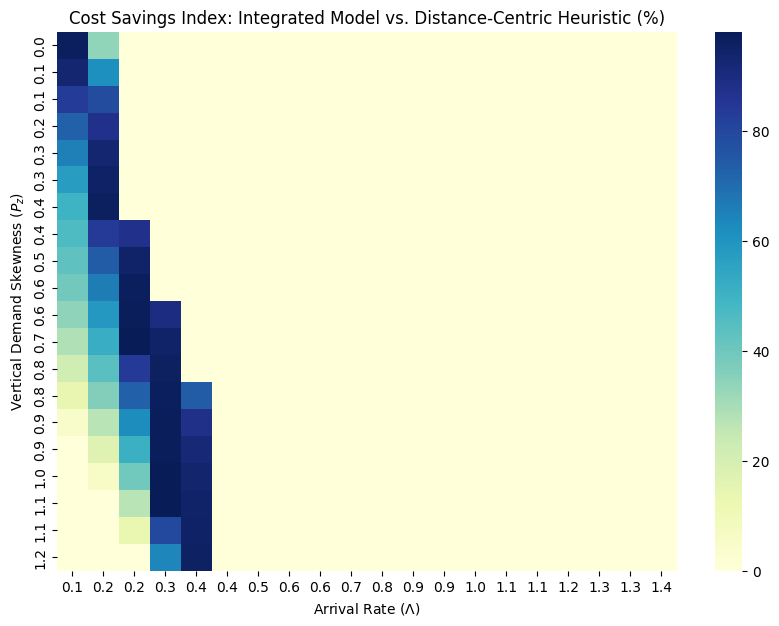

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
floors = np.arange(1, 11)
lambdas = np.linspace(0.1, 1.4, 20)
skews = np.linspace(0, 1.2, 20) # 0 = Sym, 1.2 = Top-Heavy
savings_matrix = np.zeros((len(skews), len(lambdas)))

def get_p(s):
    p = np.exp(s * (floors - 5.5))
    return p / p.sum()

def get_h(k, L, p):
    pk = p[k-1]
    edist = np.sum(p * np.abs(k - floors))
    mu = 0.5 / (edist / (1-pk+1e-6) + 0.1)
    if L >= mu*0.98: return 5000
    return 15*edist + 20*(1-pk)*(L/(mu*(mu-L)))

for i, s in enumerate(skews):
    p = get_p(s)
    c_dist = np.argmax(p) + 1 # Distance-centric floor
    for j, L in enumerate(lambdas):
        costs = [get_h(k, L, p) for k in floors]
        c_opt_cost = min(costs)
        c_dist_cost = get_h(c_dist, L, p)
        savings_matrix[i, j] = ((c_dist_cost - c_opt_cost) / c_dist_cost) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(savings_matrix, xticklabels=np.round(lambdas, 1), yticklabels=np.round(skews, 1), cmap="YlGnBu")
plt.title("Cost Savings Index: Integrated Model vs. Distance-Centric Heuristic (%)")
plt.xlabel("Arrival Rate ($\Lambda$)")
plt.ylabel("Vertical Demand Skewness ($P_z$)")
plt.show()